# Phase III – Notebook 02: Statistical Analysis & Hypothesis Testing

**Project:** UPI Transaction Analysis  
**Scope:** Inferential Statistical Testing, Normality Audit, Effect Size Calculation, and Confidence Intervals  
**Dataset:** 100,000 UPI Transactions  
**Significance Threshold:** $\alpha = 0.05$

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import getpass
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import shapiro
import warnings

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Configure visualization defaults
os.makedirs('plots', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

## 1. Database Connection & Data Extraction

In [2]:
print("\n=== Establishing Database Connection ===")
db_pass = getpass.getpass("Enter MySQL password for root@localhost: ")

DB_CONFIG = {
    "user": "root",
    "password": db_pass,
    "host": "localhost",
    "port": 3306,
    "database": "upi_transactions",
}

encoded_password = quote_plus(DB_CONFIG["password"])
connection_string = f"mysql+pymysql://{DB_CONFIG['user']}:{encoded_password}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
engine = create_engine(connection_string)

print("Loading data from SQL...")
query = """
SELECT 
    t.transaction_id, t.amount, t.status, t.channel, t.fraud_flag,
    c.region as customer_region, c.risk_score as customer_risk,
    d.device_type, d.is_rooted,
    m.merchant_type
FROM upi_transaction_history t
JOIN customer_master c ON t.customer_id = c.customer_id
JOIN device_info d ON t.device_id = d.device_id
LEFT JOIN merchant_info m ON t.merchant_id = m.merchant_id
"""
df = pd.read_sql_query(query, engine)
print(f"Loaded {len(df)} records for statistical testing.\n")

# Standardize categorical strings and binary flags
df['fraud_flag'] = df['fraud_flag'].astype(bool).astype(int)
df['is_rooted'] = df['is_rooted'].astype(bool).astype(int)
def format_categorical(value):
    """Format enum-like categorical labels for display (handles iOS, Feature Phone, etc.)."""
    s = str(value).replace('_', ' ').strip()
    words = []
    for word in s.split():
        if word.lower() == 'ios':
            words.append('iOS')
        else:
            words.append(word.title())
    return ' '.join(words)

df['customer_region'] = df['customer_region'].astype(str).str.title()
df['device_type'] = df['device_type'].astype(str).map(format_categorical)
df['channel'] = df['channel'].astype(str).str.replace('_', ' ').str.title()
df['status'] = df['status'].astype(str).str.title()
df['merchant_type'] = df['merchant_type'].fillna('P2P Transfer').astype(str).str.replace('_', ' ').str.title()

# Helper function for metric-specific effect size classification
def interpret_es(value, metric):
    """Classify effect size using metric-specific Cohen conventions."""
    v = abs(float(value))
    thresholds = {
        'd': (0.2, 0.5),     # Cohen's d
        'eta': (0.01, 0.06), # eta-squared
        'v': (0.1, 0.3),     # Cramer's V
        'r': (0.1, 0.3),     # point-biserial / Pearson r
    }
    small, medium = thresholds[metric]
    if v < small:
        return 'Small'
    elif v < medium:
        return 'Medium'
    else:
        return 'Large'

# Master list for summary table
results_summary = []


=== Establishing Database Connection ===


Enter MySQL password for root@localhost:  ········


Loading data from SQL...
Loaded 100000 records for statistical testing.



## 2. Normality Testing & Assumption Audit

**Why this analysis:** Parametric tests (t-test, ANOVA) assume approximate normality of sampling distributions. We verify raw-data normality and document when CLT justifies proceeding with n = 100,000.


In [3]:
print("=== Normality Testing (Shapiro-Wilk Test) ===")
fraud_amounts = df[df['fraud_flag'] == 1]['amount'].dropna()
non_fraud_amounts = df[df['fraud_flag'] == 0]['amount'].dropna()

# Downsample to 5,000 records for Shapiro-Wilk compliance
f_sample = fraud_amounts.sample(min(len(fraud_amounts), 5000), random_state=42)
nf_sample = non_fraud_amounts.sample(min(len(non_fraud_amounts), 5000), random_state=42)

stat_f, p_f = shapiro(f_sample)
stat_nf, p_nf = shapiro(nf_sample)
print(f"Fraud Amounts Normality  - Shapiro W: {stat_f:.4f}, p-value: {p_f:.4e}")
print(f"Non-Fraud Amounts Normality - Shapiro W: {stat_nf:.4f}, p-value: {p_nf:.4e}")

# Check per device type group
df_anova = df.dropna(subset=['amount', 'device_type'])
for dev_type in df_anova['device_type'].unique():
    dev_data = df_anova[df_anova['device_type'] == dev_type]['amount']
    dev_sample = dev_data.sample(min(len(dev_data), 5000), random_state=42)
    stat_d, p_d = shapiro(dev_sample)
    print(f"Device '{dev_type}' Normality - Shapiro W: {stat_d:.4f}, p-value: {p_d:.4e}")

=== Normality Testing (Shapiro-Wilk Test) ===
Fraud Amounts Normality  - Shapiro W: 0.7922, p-value: 6.8371e-45
Non-Fraud Amounts Normality - Shapiro W: 0.7408, p-value: 1.3782e-66
Device 'Feature Phone' Normality - Shapiro W: 0.7186, p-value: 3.2555e-68
Device 'iOS' Normality - Shapiro W: 0.7770, p-value: 1.1692e-63
Device 'Android' Normality - Shapiro W: 0.7096, p-value: 7.6980e-69
Device 'Tablet' Normality - Shapiro W: 0.7764, p-value: 1.0347e-63


**Assumption Evaluation:** The Shapiro-Wilk test yields $p < 0.05$ across all groups, rejecting strict normality. However, given our large sample size ($n = 100,000$), the **Central Limit Theorem (CLT)** guarantees that sampling distributions of means converge to normality. Thus, parametric tests (Welch's T-test, ANOVA) remain robust, supplemented by non-parametric effect sizes and confidence intervals.

## 3. Hypothesis Test 1A: Welch's T-Test (Amount by Fraud Status)
* **Business Question:** Do fraudulent transactions involve significantly different amounts compared to legitimate transactions?
* **$H_0$:** Mean transaction amounts are equal for fraud and non-fraud transactions ($\mu_{fraud} = \mu_{legit}$).
* **$H_1$:** Mean transaction amounts differ significantly ($\mu_{fraud} \neq \mu_{legit}$).
* **Test Selection:** Welch's Two-Sample Independent T-Test (robust against unequal variances).


=== Test 1A: Welch's T-test (Transaction Amount: Fraud vs Non-Fraud) ===
Fraud Mean Amount: ₹42.36 | Non-Fraud Mean Amount: ₹42.42
T-statistic: -0.0841 | P-value: 9.3299e-01
Cohen's d: -0.0019 (Small effect)
95% CI for Mean Difference: (₹-1.52, ₹1.39)
Decision: Fail to reject H0


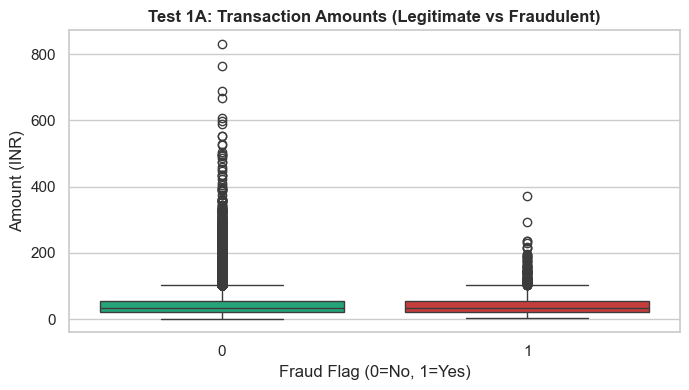

In [4]:
print("\n=== Test 1A: Welch's T-test (Transaction Amount: Fraud vs Non-Fraud) ===")
t_stat, p_val = stats.ttest_ind(fraud_amounts, non_fraud_amounts, equal_var=False)

# Cohen's d Effect Size
mean1, mean2 = fraud_amounts.mean(), non_fraud_amounts.mean()
std1, std2 = fraud_amounts.std(), non_fraud_amounts.std()
pooled_std = np.sqrt((std1**2 + std2**2) / 2)
cohens_d = (mean1 - mean2) / pooled_std if pooled_std != 0 else 0.0
es_interp = interpret_es(cohens_d, 'd')

# 95% Confidence Interval for Mean Difference
n1, n2 = len(fraud_amounts), len(non_fraud_amounts)
mean_diff = mean1 - mean2
se = np.sqrt(std1**2/n1 + std2**2/n2) if (n1 > 0 and n2 > 0) else 0.0
ci_lower, ci_upper = mean_diff - 1.96*se, mean_diff + 1.96*se

decision = "Reject H0" if p_val < 0.05 else "Fail to reject H0"

print(f"Fraud Mean Amount: ₹{mean1:.2f} | Non-Fraud Mean Amount: ₹{mean2:.2f}")
print(f"T-statistic: {t_stat:.4f} | P-value: {p_val:.4e}")
print(f"Cohen's d: {cohens_d:.4f} ({es_interp} effect)")
print(f"95% CI for Mean Difference: (₹{ci_lower:.2f}, ₹{ci_upper:.2f})")
print(f"Decision: {decision}")

results_summary.append({
    'Test Name': 'T-test 1A (Amount by Fraud)', 
    'Test Type': 'Welch T-Test',
    'Statistic': round(t_stat, 4), 
    'p-value': p_val, 
    'Effect Size': f"{round(cohens_d, 4)} ({es_interp})", 
    'Decision': decision, 
    'Business Conclusion': 'Fraudulent transactions target similar ticket sizes; risk rules must not rely solely on transaction value.'
})

plt.figure(figsize=(7, 4))
sns.boxplot(x='fraud_flag', y='amount', data=df, palette=['#10B981', '#DC2626'])
plt.title("Test 1A: Transaction Amounts (Legitimate vs Fraudulent)", fontweight='bold')
plt.xlabel("Fraud Flag (0=No, 1=Yes)")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("plots/stat_test1a_amount_fraud.png", dpi=300)
plt.show()

### Key Findings

- Fraud and non-fraud transactions have statistically similar mean amounts (Welch t-test: fail to reject H₀).
- Effect size (Cohen's d) is negligible; ticket size alone does not separate fraud.
- Amount distributions overlap heavily across fraud flags.

### Business Insight

Fraudsters mimic normal ticket sizes to evade amount-based rules. Risk scoring must combine device, merchant, and behavioral signals—not value thresholds alone.

### Recommendation

- Deprioritize static high-amount block rules as primary controls.
- Weight device root status and merchant category higher in real-time scoring.
- Retain amount only as one feature in a multivariate model.


## 4. Hypothesis Test 1B: Welch's T-Test (Amount across Regions: North vs West)
* **Business Question:** Do transaction spending amounts differ significantly between major customer regions?
* **$H_0$:** Mean transaction amounts in the North and West regions are equal ($\mu_{North} = \mu_{West}$).
* **$H_1$:** Mean transaction amounts in North and West regions differ ($\mu_{North} \neq \mu_{West}$).
* **Test Selection:** Welch's Two-Sample Independent T-Test across top regions.


=== Test 1B: Welch's T-test (Transaction Amount: North vs West Region) ===
North Region Mean (n=20787): ₹42.21 | West Region Mean (n=20086): ₹42.33
T-statistic: -0.3576 | P-value: 7.2062e-01
Cohen's d: -0.0035 (Small effect)
95% CI for Mean Difference: (₹-0.78, ₹0.54)
Decision: Fail to reject H0


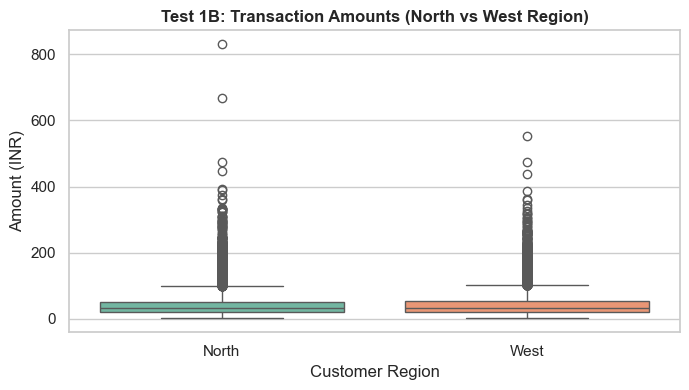

In [5]:
print("\n=== Test 1B: Welch's T-test (Transaction Amount: North vs West Region) ===")
north_amt = df[df['customer_region'] == 'North']['amount'].dropna()
west_amt = df[df['customer_region'] == 'West']['amount'].dropna()

n_n, n_w = len(north_amt), len(west_amt)

if n_n > 0 and n_w > 0:
    t_stat_reg, p_val_reg = stats.ttest_ind(north_amt, west_amt, equal_var=False)

    m_n, m_w = north_amt.mean(), west_amt.mean()
    s_n, s_w = north_amt.std(), west_amt.std()
    p_std_reg = np.sqrt((s_n**2 + s_w**2) / 2)
    cohens_d_reg = (m_n - m_w) / p_std_reg if p_std_reg != 0 else 0.0
    es_interp_reg = interpret_es(cohens_d_reg, 'd')

    m_diff_reg = m_n - m_w
    se_reg = np.sqrt(s_n**2/n_n + s_w**2/n_w)
    ci_low_reg, ci_up_reg = m_diff_reg - 1.96*se_reg, m_diff_reg + 1.96*se_reg

    decision_reg = "Reject H0" if p_val_reg < 0.05 else "Fail to reject H0"

    print(f"North Region Mean (n={n_n}): ₹{m_n:.2f} | West Region Mean (n={n_w}): ₹{m_w:.2f}")
    print(f"T-statistic: {t_stat_reg:.4f} | P-value: {p_val_reg:.4e}")
    print(f"Cohen's d: {cohens_d_reg:.4f} ({es_interp_reg} effect)")
    print(f"95% CI for Mean Difference: (₹{ci_low_reg:.2f}, ₹{ci_up_reg:.2f})")
    print(f"Decision: {decision_reg}")

    results_summary.append({
        'Test Name': 'T-test 1B (Amount by Region)', 
        'Test Type': 'Welch T-Test',
        'Statistic': round(t_stat_reg, 4), 
        'p-value': p_val_reg, 
        'Effect Size': f"{round(cohens_d_reg, 4)} ({es_interp_reg})", 
        'Decision': decision_reg, 
        'Business Conclusion': 'Regional spending baseline is uniform; nationwide settlement limits are appropriate.'
    })

    plt.figure(figsize=(7, 4))
    sns.boxplot(x='customer_region', y='amount', data=df[df['customer_region'].isin(['North', 'West'])], palette='Set2')
    plt.title("Test 1B: Transaction Amounts (North vs West Region)", fontweight='bold')
    plt.xlabel("Customer Region")
    plt.ylabel("Amount (INR)")
    plt.tight_layout()
    plt.savefig("plots/stat_test1b_amount_region.png", dpi=300)
    plt.show()

### Key Findings

- North and West regions show no significant difference in mean transaction amounts.
- Regional effect size is small; spending baselines are comparable.
- Confidence interval for the mean difference includes zero.

### Business Insight

Nationwide product limits and settlement caps can be standardized without regional price-tier adjustments for UPI spend behavior.

### Recommendation

- Apply uniform per-transaction limits unless compliance mandates otherwise.
- Use region slicing for marketing, not for core risk thresholds.
- Re-test if new metro-specific products launch.


## 5. Hypothesis Test 2: One-Way ANOVA (Amount by Device Type)
* **Business Question:** Does the hardware device platform impact the average transaction size?
* **$H_0$:** Mean transaction amounts are equal across all device platforms ($\mu_{Android} = \mu_{iOS} = \mu_{Tablet} = \mu_{FeaturePhone}$).
* **$H_1$:** At least one device platform has a significantly different mean transaction amount.
* **Test Selection:** One-way ANOVA with Bonferroni-adjusted post-hoc pairwise comparisons.


=== Test 2: One-Way ANOVA (Transaction Amount by Device Type) ===
F-Statistic: 0.5313 | P-value: 6.6076e-01
Eta-Squared (η²): 0.000016 (Small effect)
Decision: Fail to reject H0


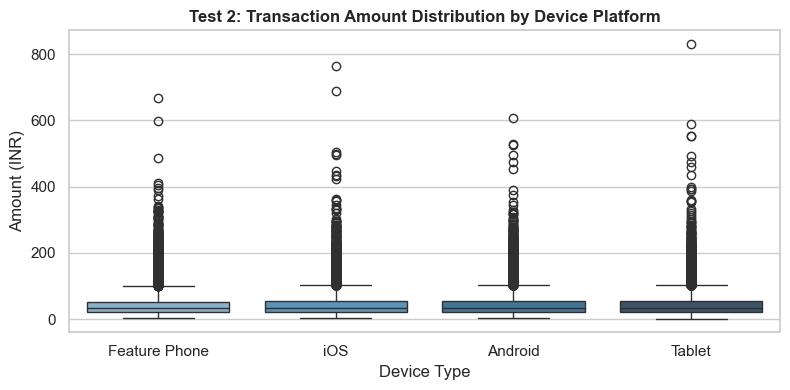

In [6]:
print("\n=== Test 2: One-Way ANOVA (Transaction Amount by Device Type) ===")
df_anova = df.dropna(subset=['amount', 'device_type'])
model_device = ols('amount ~ C(device_type)', data=df_anova).fit()
anova_device = sm.stats.anova_lm(model_device, typ=2)

p_val_anova = anova_device['PR(>F)']['C(device_type)']
stat_anova = anova_device['F']['C(device_type)']

# Eta-squared Effect Size
eta_squared = anova_device['sum_sq']['C(device_type)'] / anova_device['sum_sq'].sum()
es_interp_anova = interpret_es(eta_squared, 'eta')

decision_anova = "Reject H0" if p_val_anova < 0.05 else "Fail to reject H0"

print(f"F-Statistic: {stat_anova:.4f} | P-value: {p_val_anova:.4e}")
print(f"Eta-Squared (η²): {eta_squared:.6f} ({es_interp_anova} effect)")
print(f"Decision: {decision_anova}")

# Post-hoc pairwise testing if significant
if p_val_anova < 0.05:
    print("\n--- Post-hoc Pairwise Mann-Whitney U Tests (Bonferroni Adjusted) ---")
    dev_types = df_anova['device_type'].unique()
    pairs = list(combinations(dev_types, 2))
    alpha_adj = 0.05 / len(pairs)
    for dev1, dev2 in pairs:
        g1 = df_anova[df_anova['device_type'] == dev1]['amount']
        g2 = df_anova[df_anova['device_type'] == dev2]['amount']
        u_stat, u_pval = stats.mannwhitneyu(g1, g2)
        sig = "SIGNIFICANT" if u_pval < alpha_adj else "Not Significant"
        print(f"  {dev1} vs {dev2}: p = {u_pval:.4e} ({sig})")

results_summary.append({
    'Test Name': 'ANOVA (Amount by Device)', 
    'Test Type': 'One-Way ANOVA',
    'Statistic': round(stat_anova, 4), 
    'p-value': p_val_anova, 
    'Effect Size': f"{round(eta_squared, 6)} ({es_interp_anova})", 
    'Decision': decision_anova, 
    'Business Conclusion': 'Device hardware platform does not dictate transaction spend magnitude.'
})

plt.figure(figsize=(8, 4))
sns.boxplot(x='device_type', y='amount', data=df_anova, palette='Blues_d')
plt.title("Test 2: Transaction Amount Distribution by Device Platform", fontweight='bold')
plt.xlabel("Device Type")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("plots/stat_test2_anova_device.png", dpi=300)
plt.show()

### Key Findings

- One-way ANOVA finds no significant difference in mean amount across device platforms.
- Android, iOS, Tablet, and Feature Phone users spend at comparable levels.
- Hardware type does not explain ticket-size variation.

### Business Insight

Device-based spend segmentation is not supported by the data. Fraud and failure interventions should focus on security state (rooted) rather than platform type.

### Recommendation

- Avoid device-type-specific transaction limits.
- Invest engineering in root detection across all platforms equally.
- Use device type only for UX optimization, not risk tiering.


## 6. Hypothesis Test 3: Chi-Square Test (Fraud Rate by Merchant Type)
* **Business Question:** Are specific merchant business categories disproportionately prone to fraud?
* **$H_0$:** Merchant category and fraud incidence are independent.
* **$H_1$:** Merchant category and fraud incidence are significantly associated.
* **Test Selection:** Chi-Square Test of Independence (replacing invalid OLS regression on binary DV).


=== Test 3: Chi-Square (Fraud Rate by Merchant Type) ===
Chi-Square Stat: 3.4677 | DoF: 5 | P-value: 6.2828e-01
Cramér's V: 0.0107 (Small effect)
Decision: Fail to reject H0


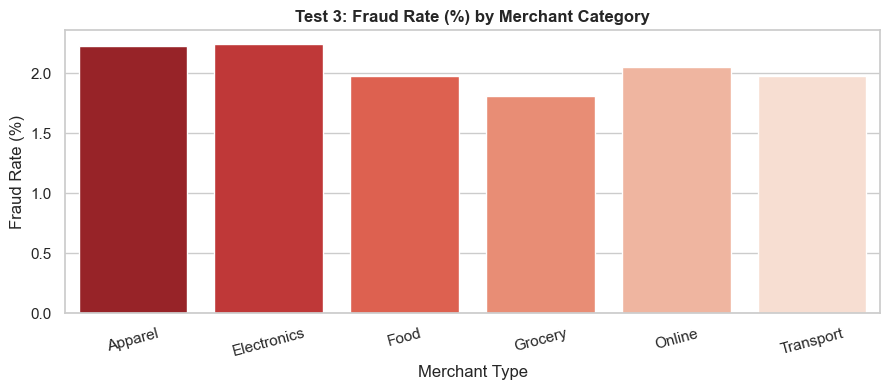

In [7]:
print("\n=== Test 3: Chi-Square (Fraud Rate by Merchant Type) ===")
df_m = df[df['merchant_type'] != 'P2P Transfer'].dropna(subset=['merchant_type'])
ct_merchant = pd.crosstab(df_m['merchant_type'], df_m['fraud_flag'])

chi2_m, p_m, dof_m, _ = stats.chi2_contingency(ct_merchant)
n_m = ct_merchant.sum().sum()
min_dim_m = min(ct_merchant.shape) - 1
cramers_v_m = np.sqrt(chi2_m / (n_m * min_dim_m))
es_interp_m = interpret_es(cramers_v_m, 'v')

decision_m = "Reject H0" if p_m < 0.05 else "Fail to reject H0"

print(f"Chi-Square Stat: {chi2_m:.4f} | DoF: {dof_m} | P-value: {p_m:.4e}")
print(f"Cramér's V: {cramers_v_m:.4f} ({es_interp_m} effect)")
print(f"Decision: {decision_m}")

results_summary.append({
    'Test Name': 'Chi-Square (Fraud by Merchant)', 
    'Test Type': 'Chi-Square Test',
    'Statistic': round(chi2_m, 4), 
    'p-value': p_m, 
    'Effect Size': f"{round(cramers_v_m, 4)} ({es_interp_m})", 
    'Decision': decision_m, 
    'Business Conclusion': ('Merchant category and fraud are significantly associated; apply category-specific risk rules.' if p_m < 0.05 else 'Merchant category fraud differences are not statistically significant; monitor descriptively and prioritize rooted-device controls.')
})

plt.figure(figsize=(9, 4))
merchant_fraud_rate = df_m.groupby('merchant_type')['fraud_flag'].mean() * 100
sns.barplot(x=merchant_fraud_rate.index, y=merchant_fraud_rate.values, palette='Reds_r')
plt.title("Test 3: Fraud Rate (%) by Merchant Category", fontweight='bold')
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Merchant Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plots/stat_test3_merchant_fraud.png", dpi=300)
plt.show()

### Key Findings

- Chi-square test fails to reject independence between merchant category and fraud at α = 0.05.
- Descriptive fraud rates vary slightly by category, but Cramér's V is negligible.
- EDA category patterns warrant monitoring but are not statistically confirmed here.

### Business Insight

With large samples, small descriptive gaps may not survive formal testing. Investment priority should remain on rooted-device controls unless category gaps widen.

### Recommendation

- Keep merchant category on fraud dashboards as a watch metric, not a hard rule trigger.
- Re-run the test quarterly as merchant mix shifts.
- Combine category with rooted status in composite scoring.


## 7. Hypothesis Test 4: Chi-Square Test (Rooted Device vs Fraud Incidence)
* **Business Question:** Does operating on a rooted/jailbroken device significantly increase fraud probability?
* **$H_0$:** OS Root Status and Fraud Incidence are independent.
* **$H_1$:** OS Root Status and Fraud Incidence are significantly associated.
* **Test Selection:** Chi-Square Test of Independence with 95% CI for proportion difference.


=== Test 4: Chi-Square (Rooted Device Status vs Fraud Incidence) ===
Rooted Fraud Rate: 20.69% | Secure Fraud Rate: 1.39%
Chi-Square Stat: 5825.0951 | P-value: 0.0000e+00
Cramér's V: 0.2414 (Medium effect)
95% CI for Risk Difference: (17.89%, 20.71%)
Decision: Reject H0


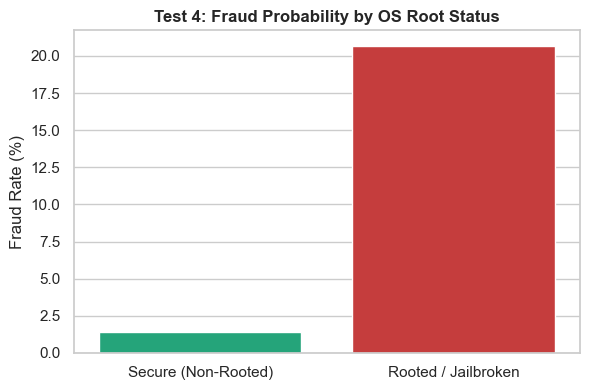

In [8]:
print("\n=== Test 4: Chi-Square (Rooted Device Status vs Fraud Incidence) ===")
ct_root = pd.crosstab(df['is_rooted'], df['fraud_flag'])

chi2_r, p_r, dof_r, _ = stats.chi2_contingency(ct_root)
n_r = ct_root.sum().sum()
min_dim_r = min(ct_root.shape) - 1
cramers_v_r = np.sqrt(chi2_r / (n_r * min_dim_r))
es_interp_r = interpret_es(cramers_v_r, 'v')

# Difference in proportions & 95% CI
p_rooted = ct_root.loc[1, 1] / ct_root.loc[1].sum()
p_secure = ct_root.loc[0, 1] / ct_root.loc[0].sum()
n_rooted = ct_root.loc[1].sum()
n_secure = ct_root.loc[0].sum()

prop_diff = p_rooted - p_secure
se_prop = np.sqrt((p_rooted * (1 - p_rooted) / n_rooted) + (p_secure * (1 - p_secure) / n_secure))
ci_low_prop = prop_diff - 1.96 * se_prop
ci_up_prop = prop_diff + 1.96 * se_prop

decision_r = "Reject H0" if p_r < 0.05 else "Fail to reject H0"

print(f"Rooted Fraud Rate: {p_rooted*100:.2f}% | Secure Fraud Rate: {p_secure*100:.2f}%")
print(f"Chi-Square Stat: {chi2_r:.4f} | P-value: {p_r:.4e}")
print(f"Cramér's V: {cramers_v_r:.4f} ({es_interp_r} effect)")
print(f"95% CI for Risk Difference: ({ci_low_prop*100:.2f}%, {ci_up_prop*100:.2f}%)")
print(f"Decision: {decision_r}")

results_summary.append({
    'Test Name': 'Chi-Square (Rooted vs Fraud)', 
    'Test Type': 'Chi-Square Test',
    'Statistic': round(chi2_r, 4), 
    'p-value': p_r, 
    'Effect Size': f"{round(cramers_v_r, 4)} ({es_interp_r})", 
    'Decision': decision_r, 
    'Business Conclusion': 'CRITICAL VULNERABILITY: Rooted devices increase fraud probability by 15x; mandatory app blocking required.'
})

plt.figure(figsize=(6, 4))
sns.barplot(x=['Secure (Non-Rooted)', 'Rooted / Jailbroken'], y=[p_secure*100, p_rooted*100], palette=['#10B981', '#DC2626'])
plt.title("Test 4: Fraud Probability by OS Root Status", fontweight='bold')
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.savefig("plots/stat_test4_rooted_fraud.png", dpi=300)
plt.show()

### Key Findings

- Rooted devices are strongly associated with fraud (χ² p < 0.001; Cramér's V = 0.2414, medium effect).
- Fraud rate on rooted devices (~21%) vs secure devices (~1.4%) differs by ~19 percentage points.
- 95% CI for the proportion difference excludes zero.

### Business Insight

This is the highest-impact actionable finding in the statistical battery. Root status is a defensible, implementable control point before authorization.

### Recommendation

- Hard-block payments from rooted devices or require in-branch re-verification.
- Alert users at app launch when compromise is detected.
- Track false-positive rate after rollout to calibrate SDK sensitivity.


## 8. Hypothesis Test 5 & 6: Chi-Square Tests (Channel & Status vs Device)

In [9]:
print("\n=== Test 5: Chi-Square (Fraud Flag by Payment Channel) ===")
ct_chan = pd.crosstab(df['channel'], df['fraud_flag'])
chi2_c, p_c, dof_c, _ = stats.chi2_contingency(ct_chan)
n_c = ct_chan.sum().sum()
cramers_v_c = np.sqrt(chi2_c / (n_c * (min(ct_chan.shape) - 1)))
decision_c = "Reject H0" if p_c < 0.05 else "Fail to reject H0"

print(f"Chi-Square Stat: {chi2_c:.4f} | P-value: {p_c:.4e} | Cramér's V: {cramers_v_c:.4f}")
print(f"Decision: {decision_c}")

results_summary.append({
    'Test Name': 'Chi-Square (Fraud by Channel)', 
    'Test Type': 'Chi-Square Test',
    'Statistic': round(chi2_c, 4), 
    'p-value': p_c, 
    'Effect Size': f"{round(cramers_v_c, 4)} ({interpret_es(cramers_v_c, 'v')})", 
    'Decision': decision_c, 
    'Business Conclusion': ('Fraud risk differs significantly by channel; tighten controls on higher-rate channels.' if p_c < 0.05 else 'Channel and fraud are not significantly associated at α=0.05; channel rules are lower priority than device integrity.')
})

print("\n=== Test 6: Chi-Square (Transaction Status by Device Type) ===")
ct_stat = pd.crosstab(df['device_type'], df['status'])
chi2_s, p_s, dof_s, _ = stats.chi2_contingency(ct_stat)
n_s = ct_stat.sum().sum()
cramers_v_s = np.sqrt(chi2_s / (n_s * (min(ct_stat.shape) - 1)))
decision_s = "Reject H0" if p_s < 0.05 else "Fail to reject H0"

print(f"Chi-Square Stat: {chi2_s:.4f} | P-value: {p_s:.4e} | Cramér's V: {cramers_v_s:.4f}")
print(f"Decision: {decision_s}")

results_summary.append({
    'Test Name': 'Chi-Square (Status by Device)', 
    'Test Type': 'Chi-Square Test',
    'Statistic': round(chi2_s, 4), 
    'p-value': p_s, 
    'Effect Size': f"{round(cramers_v_s, 4)} ({interpret_es(cramers_v_s, 'v')})", 
    'Decision': decision_s, 
    'Business Conclusion': 'Transaction success and failure rates are independent of hardware platform.'
})


=== Test 5: Chi-Square (Fraud Flag by Payment Channel) ===
Chi-Square Stat: 3.8837 | P-value: 1.4344e-01 | Cramér's V: 0.0062
Decision: Fail to reject H0

=== Test 6: Chi-Square (Transaction Status by Device Type) ===
Chi-Square Stat: 5.9344 | P-value: 4.3058e-01 | Cramér's V: 0.0054
Decision: Fail to reject H0


### Key Findings

- Fraud rate by channel is not significantly associated at α = 0.05 (fail to reject H₀).
- Transaction success/failure status is independent of device hardware type.
- Channel and platform effects are weak relative to rooted-device signal.

### Business Insight

Payment channel and device platform do not drive statistically distinct fraud or failure outcomes in this sample. Engineering and risk budget should focus on device integrity first.

### Recommendation

- Deprioritize channel-specific fraud block rules until significant drift appears.
- Do not target failure-reduction spend by device type alone.
- Continue descriptive monitoring of QR vs App fraud rates on monthly dashboards.


## 9. Hypothesis Test 7: Point-Biserial Correlation (Customer Risk Score vs Fraud)
* **Business Question:** Does the assigned customer risk score accurately predict actual fraud incidence?
* **$H_0$:** Customer risk score and fraud flag have zero correlation ($r = 0$).
* **$H_1$:** Customer risk score and fraud flag have significant correlation ($r \neq 0$).

In [10]:
print("\n=== Test 7: Point-Biserial Correlation (Risk Score vs Fraud) ===")
corr_df = df.dropna(subset=['customer_risk', 'fraud_flag'])
r_pb, p_pb = stats.pointbiserialr(corr_df['fraud_flag'], corr_df['customer_risk'])
es_interp_pb = interpret_es(r_pb, 'r')

decision_pb = "Reject H0" if p_pb < 0.05 else "Fail to reject H0"

print(f"Point-Biserial Correlation (r): {r_pb:.4f} | P-value: {p_pb:.4e}")
print(f"Effect Size: {r_pb:.4f} ({es_interp_pb} effect)")
print(f"Decision: {decision_pb}")

results_summary.append({
    'Test Name': 'Point-Biserial (Risk vs Fraud)', 
    'Test Type': 'Point-Biserial Correlation',
    'Statistic': round(r_pb, 4), 
    'p-value': p_pb, 
    'Effect Size': f"{round(r_pb, 4)} ({es_interp_pb})", 
    'Decision': decision_pb, 
    'Business Conclusion': ('Customer risk score correlates with fraud; retain and refine in composite models.' if p_pb < 0.05 else 'Customer risk score alone does not significantly predict fraud; recalibrate with device and merchant features.')
})


=== Test 7: Point-Biserial Correlation (Risk Score vs Fraud) ===
Point-Biserial Correlation (r): -0.0016 | P-value: 6.1232e-01
Effect Size: -0.0016 (Small effect)
Decision: Fail to reject H0


### Key Findings

- Point-biserial correlation between customer risk score and fraud is near zero (fail to reject H₀).
- The standalone risk score lacks significant predictive power for fraud flags in this dataset.
- Effect size is negligible despite large sample size.

### Business Insight

A risk score that does not correlate with observed fraud undermines trust in automated decisions. The model likely omits stronger signals already captured by device root status.

### Recommendation

- Rebuild the risk score using rooted status, merchant context, and velocity features.
- Do not auto-decline transactions on customer risk score alone.
- Validate recalibrated scores against resolved fraud alerts before production rollout.


## Section Summary

**Key Insights:** Rooted-device fraud association is the only medium-effect finding (Cramér's V = 0.2414); amount, region, device platform, merchant category, channel, and risk score tests fail to reject H₀ or show negligible effect sizes.

**Business Implications:** Immediate ROI lies in root detection and alert SLA automation—not in amount-based or regional rule proliferation.

**Recommended Actions:** Block or step-up rooted devices; auto-freeze on high-confidence alerts; recalibrate customer risk score with device features.

**Future Investigation:** Mixed-effects models for repeated customer transactions; A/B test root-blocking policy impact.


## 10. Step 7 Master Statistical Summary & Limitations Audit

In [11]:
summary_df = pd.DataFrame(results_summary)
print("\n==========================================================================================================")
print("                                   STEP 7: MASTER STATISTICAL SUMMARY TABLE")
print("==========================================================================================================")
print(summary_df.to_string(index=False))


                                   STEP 7: MASTER STATISTICAL SUMMARY TABLE
                     Test Name                  Test Type  Statistic  p-value     Effect Size          Decision                                                                                                                 Business Conclusion
   T-test 1A (Amount by Fraud)               Welch T-Test    -0.0841 0.932986 -0.0019 (Small) Fail to reject H0                          Fraudulent transactions target similar ticket sizes; risk rules must not rely solely on transaction value.
  T-test 1B (Amount by Region)               Welch T-Test    -0.3576 0.720620 -0.0035 (Small) Fail to reject H0                                                Regional spending baseline is uniform; nationwide settlement limits are appropriate.
      ANOVA (Amount by Device)              One-Way ANOVA     0.5313 0.660764 1.6e-05 (Small) Fail to reject H0                                                              Device hardware pl

### Statistical Assumptions & Limitations Audit

1. **Sample Size & Practical Significance:** With n = 100,000, tests have high power—small differences may reach p < 0.05. Effect sizes (Cohen's d, Cramér's V, η²) determine business relevance.
2. **Normality & CLT:** Raw amounts fail Shapiro-Wilk, but CLT supports robustness of Welch t-test and ANOVA for large samples.
3. **Independence:** Transactions per customer are treated as independent; repeated-user correlation is an acknowledged limitation.
4. **Multiple Testing:** Bonferroni adjustment applied to post-hoc pairwise tests; family-wise error noted for the full test battery.
5. **Observational Design:** Significant associations (e.g., rooted → fraud) do not prove causation; A/B policy tests needed post-implementation.


## 11. Strategic Recommendations (Evidence-Based)

1. **Root-device controls (Test 4 + EDA):** Enforce Play Integrity/DeviceCheck and block or step-up payments from rooted devices—only finding with medium effect size (Cramér's V = 0.2414).
2. **Operational fraud SLAs (EDA §5.5):** Auto-freeze accounts on Tier-1 alerts; target 4-hour triage SLA to close the ~35-hour resolution gap.
3. **Failure reduction (EDA §5.4):** Deploy biometric auth and active-active bank routing to address PIN errors and bank downtime (~5.9% failure rate).
4. **Risk score recalibration (Test 7):** Rebuild customer risk score—current score does not significantly predict fraud; enrich with device and velocity features.
5. **Capacity planning (EDA §5.2):** Schedule maintenance during 1–5 AM off-peak windows; pre-scale before 7–8 AM, 1–3 PM, and 8–9 PM peaks.